## 1. Import required libraries

In [1]:
# Regular expressions for text cleaning
import re
from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Text cleaning
import contractions
import emoji

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Word cloud visualization
from wordcloud import WordCloud, STOPWORDS

# Topic modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Dimensionality reduction for embedding visualization
from sklearn.manifold import TSNE
import umap

# Sentence embeddings
from sentence_transformers import SentenceTransformer

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

C:\Users\Seyoung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### What these libraries do

- **pandas / numpy** are used for working with structured data.
- **matplotlib / seaborn** are used to make plots.
- **wordcloud** is used to visualize frequent words.
- **CountVectorizer** converts cleaned text into a document-term matrix for topic modeling.
- **LatentDirichletAllocation** discovers hidden topics in the text.
- **SentenceTransformer** converts posts into dense semantic vectors.
- **t-SNE / UMAP** reduce high-dimensional embeddings into two dimensions for visualization.

## 2. Load the dataset

In [4]:
# Load labeled training data and unlabeled test data

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Basic cleanup
train_df["text"] = train_df["text"].fillna("").astype(str)
train_df["status"] = train_df["status"].astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))

display(train_df.head())
display(test_df.head())

print("\nTraining class distribution:")
display(train_df["status"].value_counts())

Train shape: (41174, 3)
Test shape: (8436, 2)

Train columns: ['id', 'text', 'status']
Test columns: ['id', 'text']


,id,text,status
0,37183,i wish i wa in sydney,Normal
1,10228,being an adult is so fucking lonely. everyone ...,Suicidal
2,18073,"I would assume not, considering I could just f...",Suicidal
3,1576,I just realized that yesterday I haven't eaten...,Normal
4,12577,"Day #1Decided to not kill myself today, and I ...",Suicidal


,id,text
0,37716,be offline
1,17470,"I cannot fucking take this shit anymore, my fa..."
2,7630,I am in a really dark place right now and I ju...
3,9138,Its pointless. Fuck This world Yeah fuck it
4,11713,I have had a rough week or so. I have been thi...



Training class distribution:


status
Normal        16281
Depression    12397
Suicidal       9102
Anxiety        3394
Name: count, dtype: int64

## 3. Regular text cleaning

In [10]:
# Text Cleaning
# - lowercase text
# - expanded contractions
# - no URLs / no @mentions
# - hashtag normalization (#sad -> sad)
# - repeated character normalization
# - digits
# - emotional punctuation ! and ?
#
# We keep ! and ? because they may signal emotional intensity in social media posts.

def clean_text_for_model(text):
    text = str(text)

    # Normalize curly apostrophes and similar variants
    text = text.replace("’", "'").replace("`", "'")

    # Lowercase for consistency
    text = text.lower()

    # Expand contractions: "can't" -> "cannot"
    text = contractions.fix(text)

    # Remove URLs.
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags if any.
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove mentions like @username
    text = re.sub(r"@\w+", " ", text)

    # Normalize hashtags by removing # but keeping the word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Convert emojis to text descriptions
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Normalize elongated words: "sooooo" -> "soo"
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Keep letters, digits, spaces, ! and ?
    text = re.sub(r"[^a-z0-9!? ]", " ", text)

    # Collapse repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply corrected cleaning to both datasets.
train_df["clean_text_model"] = train_df["text"].apply(clean_text_for_model)
test_df["clean_text_model"] = test_df["text"].apply(clean_text_for_model)

# Create a dedicated EDA dataframe for downstream analysis
df = train_df.copy()
df["clean_text"] = df["clean_text_model"]

display(train_df[["text", "clean_text_model"]].head(10))

,text,clean_text_model
0,i wish i wa in sydney,i wish i wa in sydney
1,being an adult is so fucking lonely. everyone ...,being an adult is so fucking lonely everyone i...
2,"I would assume not, considering I could just f...",i would assume not considering i could just fa...
3,I just realized that yesterday I haven't eaten...,i just realized that yesterday i have not eate...
4,"Day #1Decided to not kill myself today, and I ...",day 1decided to not kill myself today and i am...
5,yakedoshita,yakedoshita
6,17F. I’ve been fantasizing about this night si...,17f i have been fantasizing about this night s...
7,found 2 cockroaches on my bed and one in my cl...,found 2 cockroaches on my bed and one in my cl...
8,I had a moment earlier when I was setting up f...,i had a moment earlier when i was setting up f...
9,the one that stole a small plane?,the one that stole a small plane?


## 4. Stopwords and label order

In [6]:
# Base stopword list
stopwords = set(STOPWORDS)

# Keep negation because it can be meaningful in mental health language
for word in ["not", "no", "nor"]:
    stopwords.discard(word)

# Add extra filler words to make frequency charts and word clouds more interpretable
# this means including extra_stop in stopwords
# which means excluding them from the text
# extra_stop = {
#     "im", "ive", "id", "ill", "dont", "cant", "didnt", "doesnt", "isnt", "wasnt", "wont",
#     "thing", "things", "stuff", "really", "going", "people", "person", "someone", "everyone",
#     "anything", "everything", "something", "know", "time", "day", "today", "year", "years",
#     "friend", "friends", "school", "work", "make", "made", "want", "need", "still", "even",
#     "well", "one", "also", "just", "like", "got", "get", "getting", "say", "said", "tell",
#     "told", "think", "thought", "back", "much", "will"
# }

# stopwords |= extra_stop

labels_in_order = ["Suicidal", "Depression", "Anxiety", "Normal"]
counts = df["status"].value_counts().to_dict()

## 5. Word frequency charts by category

In [11]:
# Return the top n most frequent cleaned words by category.

def top_words_for_label(label, n=15):
    words = " ".join(df.loc[df["status"] == label, "clean_text"]).split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

# Print top words in text form
for label in labels_in_order:
    print(f"\nTop words for {label}:")
    print(top_words_for_label(label, n=15))


Top words for Suicidal:
[('not', 19607), ('want', 7481), ('life', 5111), ('will', 5058), ('feel', 4993), ('know', 4814), ('now', 3141), ('going', 3098), ('people', 3076), ('even', 3061), ('one', 2799), ('time', 2653), ('really', 2595), ('think', 2552), ('die', 2375)]

Top words for Depression:
[('not', 22501), ('feel', 9548), ('want', 7003), ('life', 6668), ('know', 6164), ('will', 4659), ('even', 4622), ('people', 4599), ('depression', 4387), ('time', 4190), ('now', 4156), ('really', 3879), ('one', 3393), ('going', 3203), ('day', 3119)]

Top words for Anxiety:
[('not', 6319), ('anxiety', 3191), ('feel', 2185), ('will', 1622), ('know', 1590), ('now', 1388), ('time', 1297), ('really', 1281), ('even', 1178), ('going', 1176), ('people', 1151), ('something', 962), ('one', 950), ('want', 933), ('day', 913)]

Top words for Normal:
[('not', 5587), ('mom', 2733), ('will', 1607), ('want', 1515), ('know', 1211), ('really', 1095), ('one', 1075), ('now', 1006), ('time', 961), ('people', 960), ('d

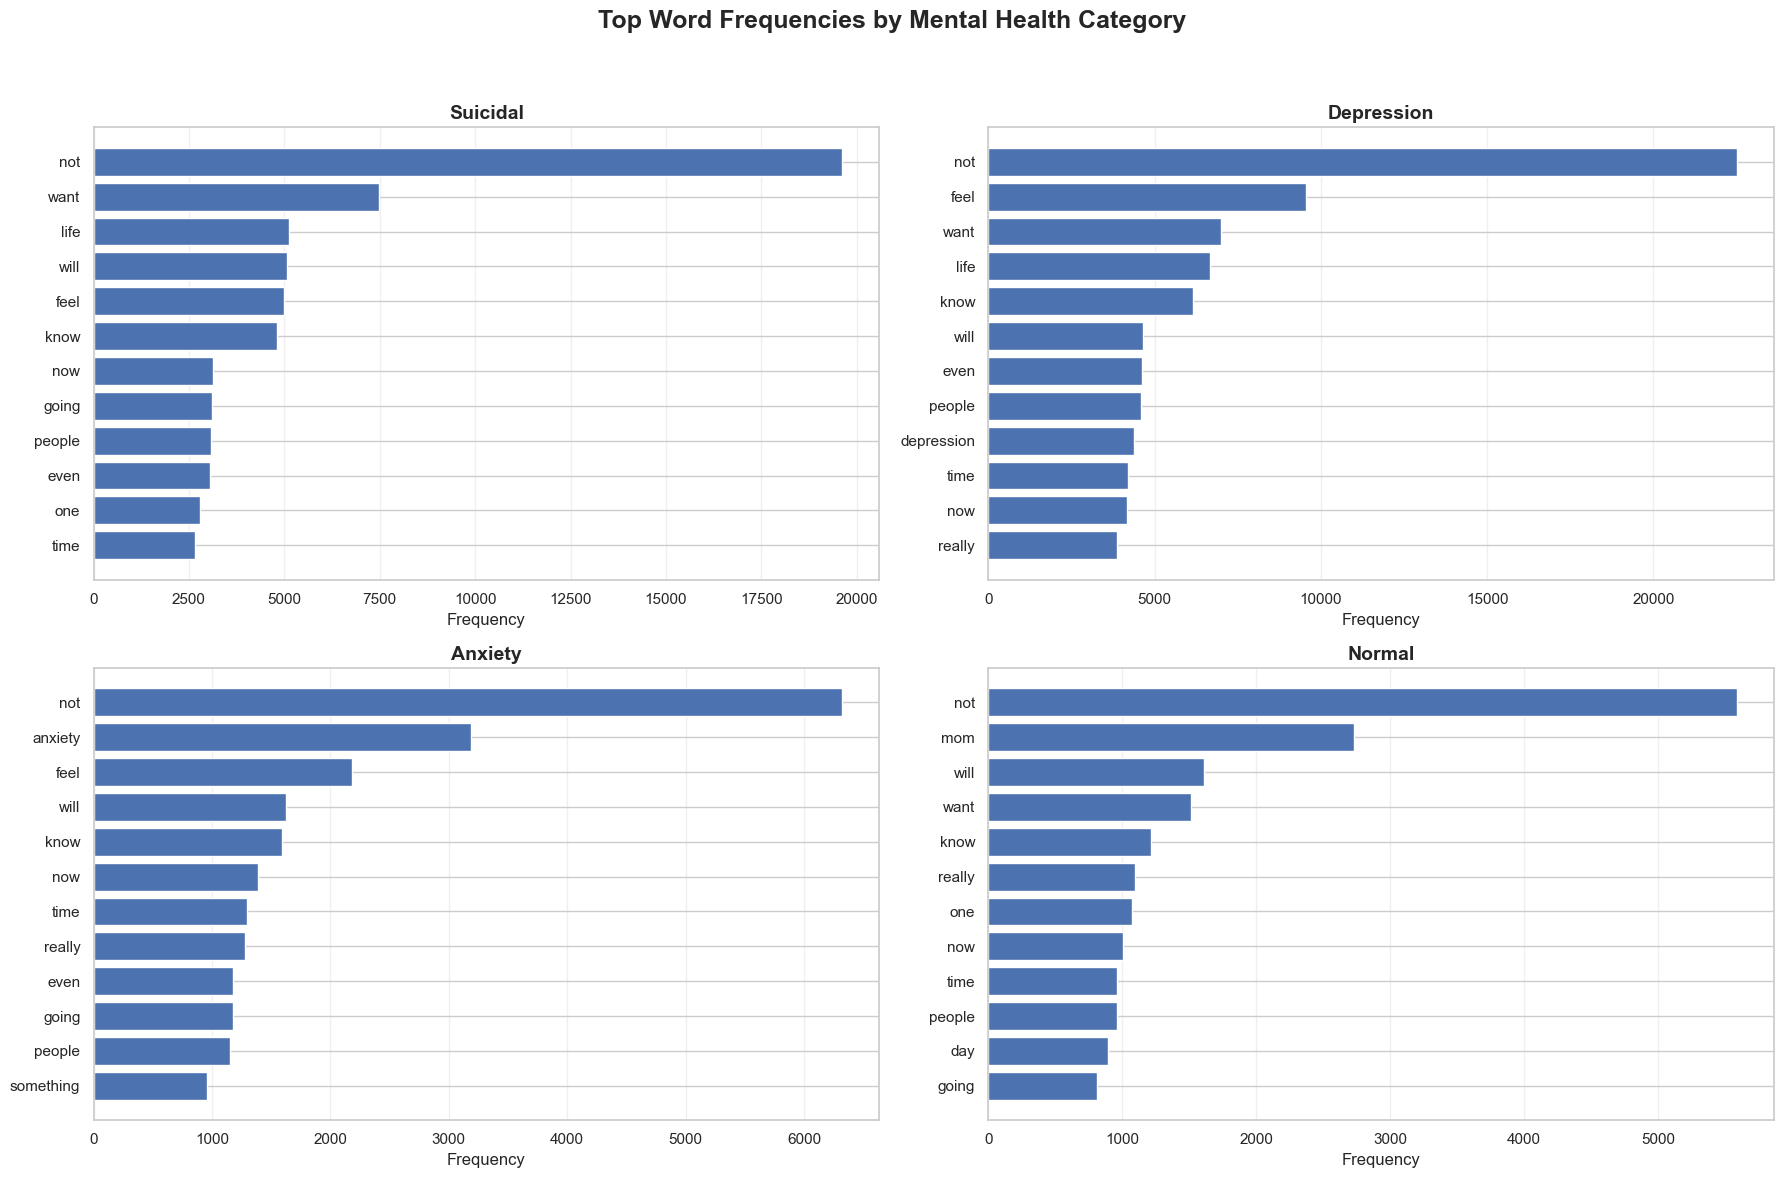

In [12]:
# Plot word frequency bar charts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Top Word Frequencies by Mental Health Category", fontsize=18, fontweight="bold", y=0.98)

for ax, label in zip(axes.flatten(), labels_in_order):
    top_words = top_words_for_label(label, n=12)
    words = [w for w, c in top_words]
    freqs = [c for w, c in top_words]

    ax.barh(list(reversed(words)), list(reversed(freqs)))
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### What the word frequency charts show

These bar charts show the most frequent cleaned words in each category after removing common stopwords and generic filler words. Compared with word clouds, bar charts are often easier to read because they allow direct comparison of frequencies. They help identify which terms are especially common within suicidal, depression, anxiety, and normal posts.

## 6. Word clouds by category

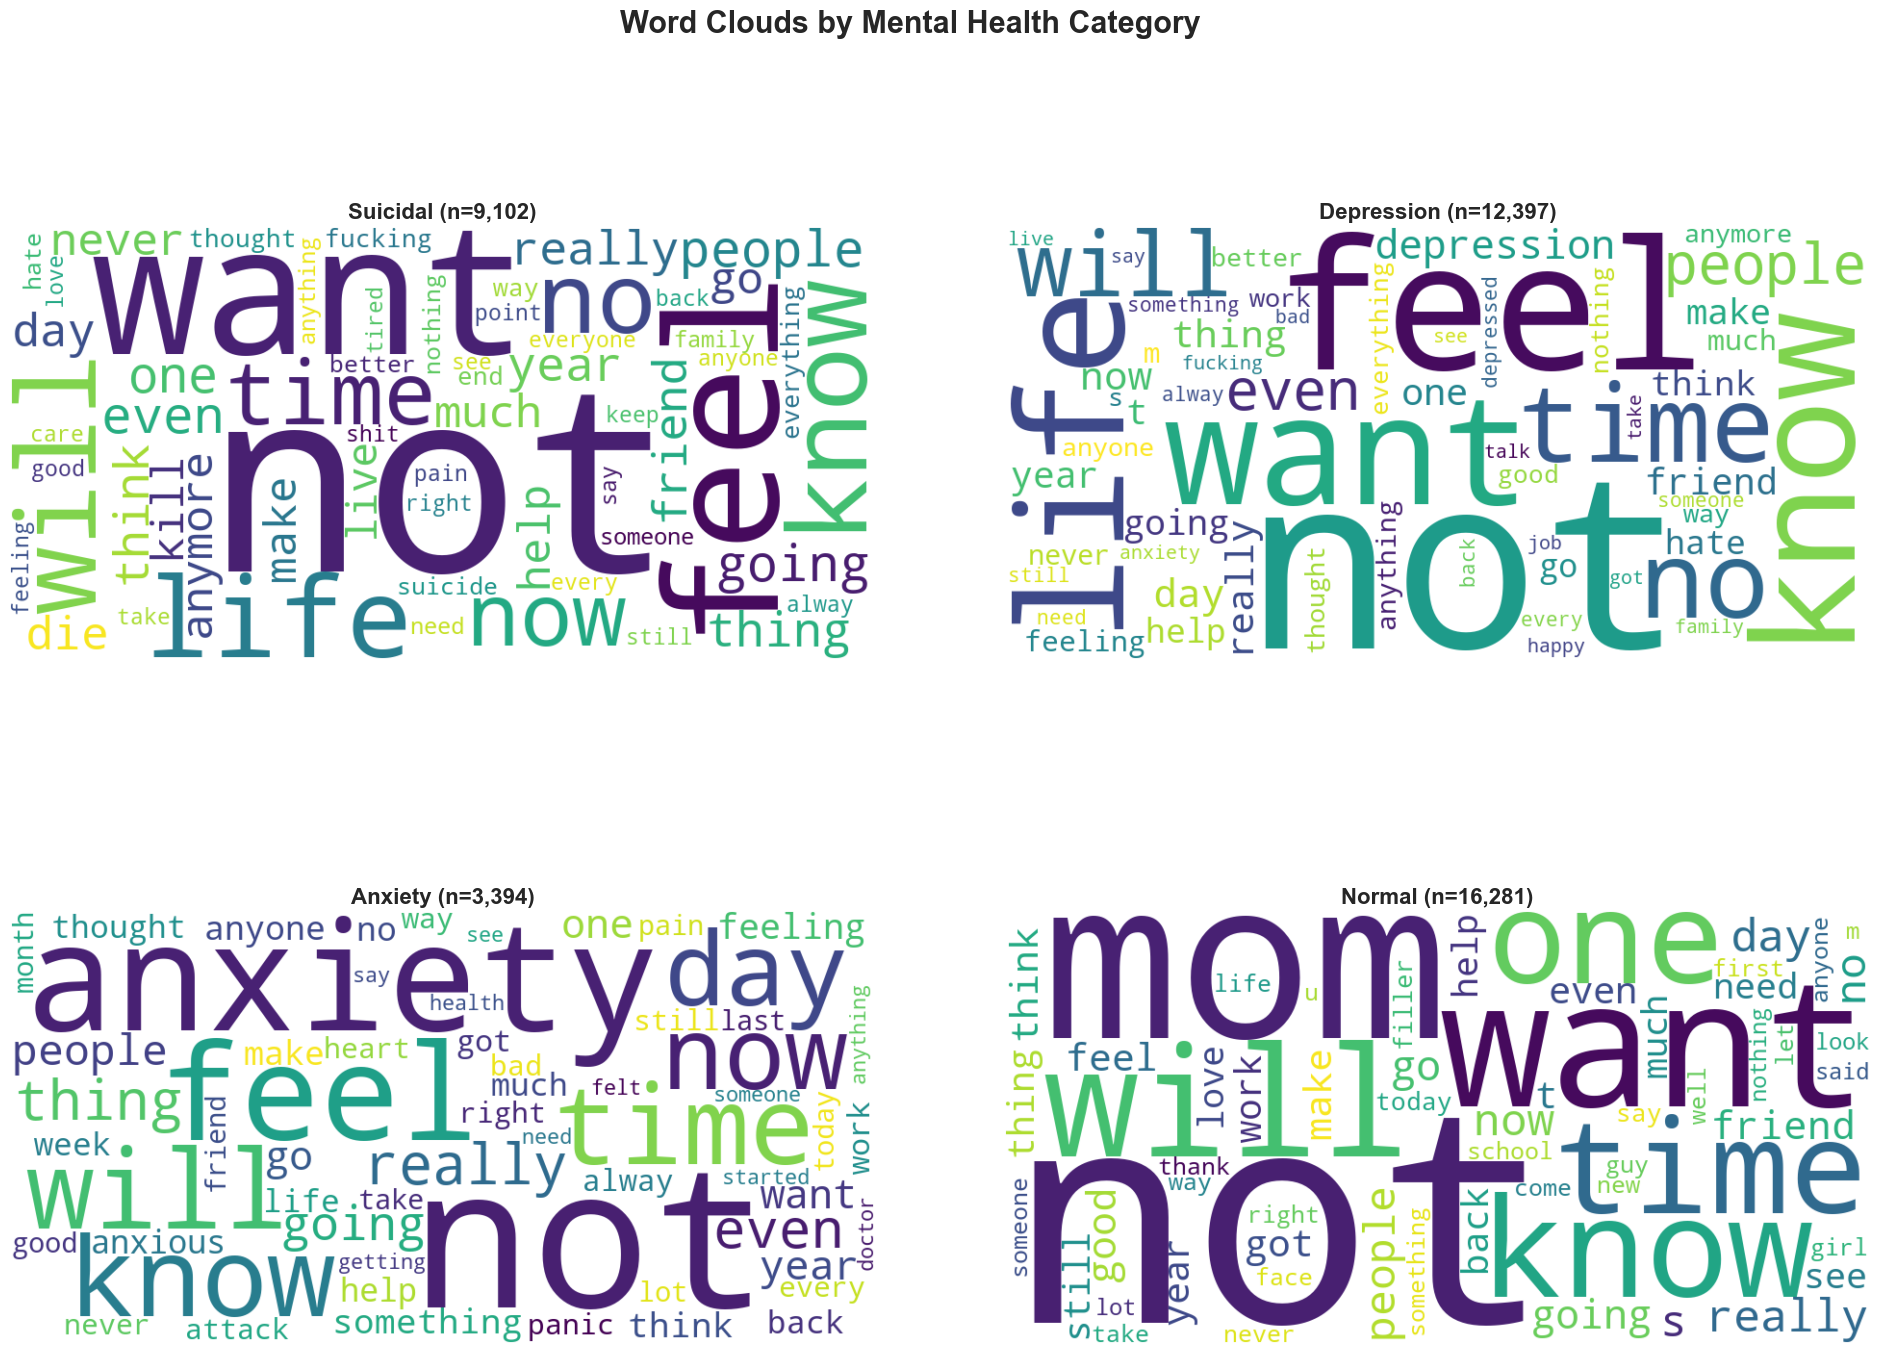

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
fig.suptitle("Word Clouds by Mental Health Category", fontsize=22, fontweight="bold", y=0.98)

for ax, label in zip(axes.flatten(), labels_in_order):
    # Combine all cleaned text for the current category
    text_blob = " ".join(df.loc[df["status"] == label, "clean_text"].tolist())

    # Generate word cloud
    wc = WordCloud(
        background_color="white",
        stopwords=stopwords,
        max_words=60,
        width=900,
        height=450,
        colormap="viridis",
        collocations=False,
        prefer_horizontal=0.9,
        random_state=42
    ).generate(text_blob)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label} (n={counts.get(label, 0):,})", fontsize=16, fontweight="bold")
    ax.axis("off")

plt.subplots_adjust(hspace=0.25, wspace=0.15)
plt.show()

### What the word clouds show

Word clouds provide a quick qualitative view of the most common words in each class. Larger words appear more often. This is helpful for fast visual inspection, but word clouds should be interpreted cautiously because they emphasize frequency rather than context or statistical distinctiveness.

## 7. LDA topic modeling

LDA is an unsupervised learning method that identifies hidden themes in a collection of documents. It assumes that each document is a mixture of topics, and each topic is a mixture of words.

In [15]:
# Convert cleaned text into a document-term matrix for LDA
lda_vectorizer = CountVectorizer(
    stop_words=list(stopwords),
    max_df=0.95,
    min_df=10
)

X_counts = lda_vectorizer.fit_transform(df["clean_text"])
feature_names = lda_vectorizer.get_feature_names_out()

print("Document-term matrix shape:", X_counts.shape)

C:\Users\Seyoung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Document-term matrix shape: (41174, 7285)


In [16]:
# Train LDA
n_topics = 8

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_model.fit(X_counts)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",8
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [17]:
# Print the top words in each latent topic

def print_topics(model, feature_names, n_words=12):
    # model.components_ contains the word distribution for each topic
    for topic_idx, topic in enumerate(model.components_):
        # sorts words by importance in the topic
        # takes the top 12 words
        # reverse the order so highest importance appears first
        top_idx = topic.argsort()[-n_words:][::-1]
        # since the model only knows word indices, this converts them back into actual vocabulary words
        words = [feature_names[i] for i in top_idx]
        print(f"Topic {topic_idx + 1}: {', '.join(words)}")

print_topics(lda_model, feature_names, n_words=12)

Topic 1: not, people, one, time, will, really, friend, said, told, good, got, post
Topic 2: life, not, hate, people, will, no, fucking, want, never, one, love, live
Topic 3: not, feel, want, know, even, people, really, anymore, anything, tired, think, feeling
Topic 4: not, day, will, today, oh, want, good, yes, morning, let, no, music
Topic 5: not, will, want, no, going, know, life, now, one, anymore, go, years
Topic 6: not, anxiety, now, sleep, day, feel, night, heart, go, back, going, panic
Topic 7: mom, job, don, work, wa, fuck, ve, school, depression, year, got, ha
Topic 8: not, feel, depression, know, anxiety, now, really, help, time, things, years, thoughts


In [19]:
# Compute topic proportions for each post
topic_distributions = lda_model.transform(X_counts)

# convert it to DataFrame
topic_cols = [f"Topic_{i+1}" for i in range(n_topics)]
topic_df = pd.DataFrame(topic_distributions, columns=topic_cols)
# attach category label
topic_df["status"] = df["status"].values

# average topic distribution by class
avg_topics_by_class = topic_df.groupby("status").mean()
display(avg_topics_by_class.round(3))

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8
status,,,,,,,,
Anxiety,0.107,0.045,0.097,0.040,0.054,0.432,0.028,0.197
Depression,0.087,0.149,0.228,0.040,0.136,0.076,0.072,0.211
Normal,0.190,0.085,0.107,0.267,0.079,0.106,0.106,0.060
Suicidal,0.074,0.238,0.181,0.034,0.292,0.048,0.030,0.103


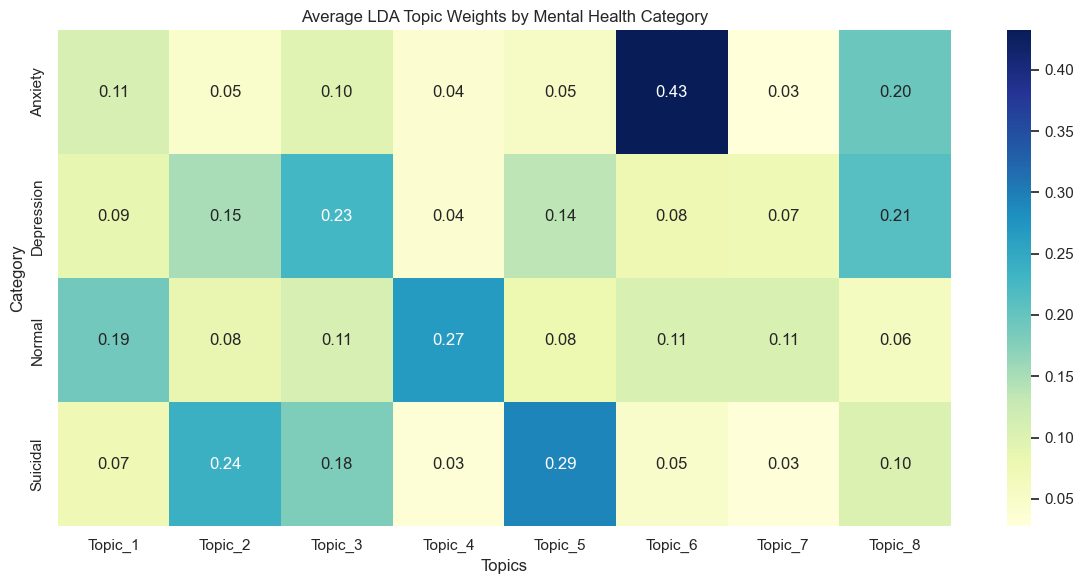

In [20]:
plt.figure(figsize=(12, 6))
sns.heatmap(avg_topics_by_class, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Average LDA Topic Weights by Mental Health Category")
plt.xlabel("Topics")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### What LDA adds to EDA

Unlike word clouds or raw frequency charts, LDA tries to uncover broader themes in the dataset. For example, one topic might contain words related to panic or physical symptoms, while another topic may contain words related to hopelessness, death, or social relationships. The topic-weight heatmap shows whether different categories tend to emphasize different topics on average.

## 8. Sentence embeddings

Sentence embeddings convert each post into a dense numerical vector that captures semantic meaning. To keep runtime manageable, we take a balanced sample from each class before visualizing embeddings.

In [21]:
sample_n_per_class = 500

df_sample = (
    df.groupby("status", group_keys=False)
      .apply(lambda x: x.sample(n=min(sample_n_per_class, len(x)), random_state=42))
      .reset_index(drop=True)
)

print(df_sample["status"].value_counts())

status
Anxiety       500
Depression    500
Normal        500
Suicidal      500
Name: count, dtype: int64


C:\Users\Seyoung\AppData\Local\Temp\ipykernel_29400\4079255536.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(sample_n_per_class, len(x)), random_state=42))


In [22]:
# Load pretrained embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert sampled cleaned text into embeddings
sample_embeddings = embedding_model.encode(
    df_sample["clean_text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

print("Embedding shape:", sample_embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3538.66it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 63/63 [00:06<00:00, 10.43it/s]

Embedding shape: (2000, 384)


## 9. t-SNE visualization

In [23]:
# sentence embeddings usually have a very high dimensionality, and t-SNE reudceds them to 2 dimensions.
tsne = TSNE(
    n_components=2, # reduce data to 2 dimensions
    perplexity=30, # approximate neighborhood size
    random_state=42,
    init="pca", # optimization with pca
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(sample_embeddings)

# attach 2D coordinates with labels
tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "status": df_sample["status"].values
})

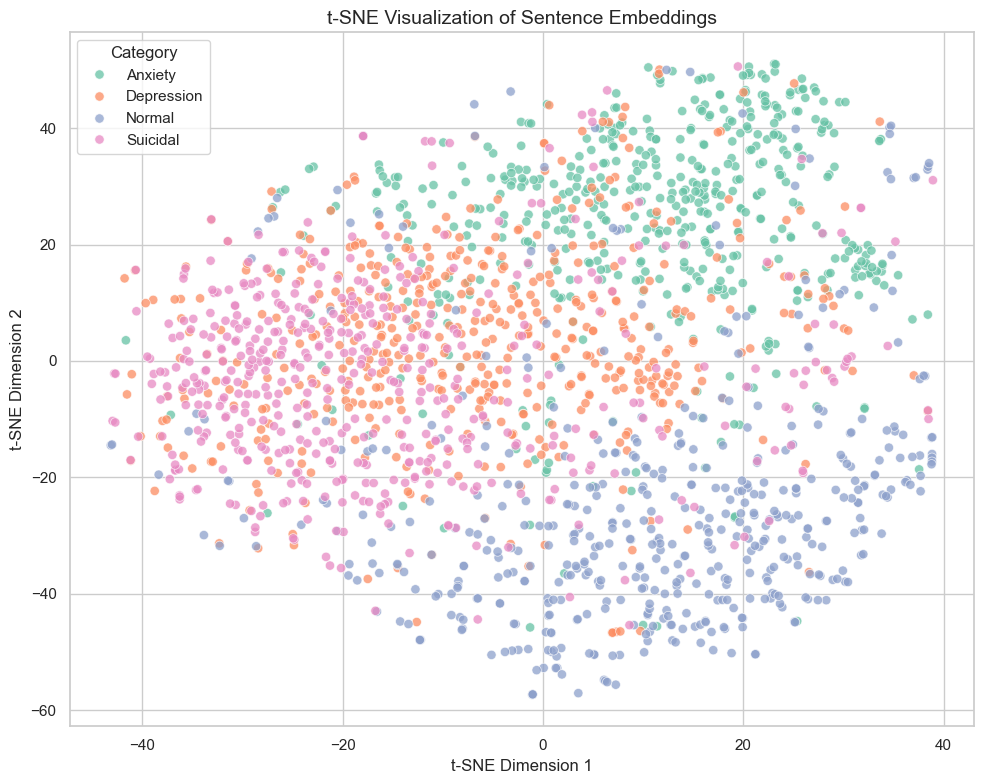

In [24]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=tsne_df,
    x="x",
    y="y",
    hue="status",
    palette="Set2",
    alpha=0.75,
    s=45
)

plt.title("t-SNE Visualization of Sentence Embeddings", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

## 10. UMAP visualization

In [25]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1, # how tightly clusters form
    random_state=42
)

X_umap = umap_reducer.fit_transform(sample_embeddings)

umap_df = pd.DataFrame({
    "x": X_umap[:, 0],
    "y": X_umap[:, 1],
    "status": df_sample["status"].values
})

C:\Users\Seyoung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


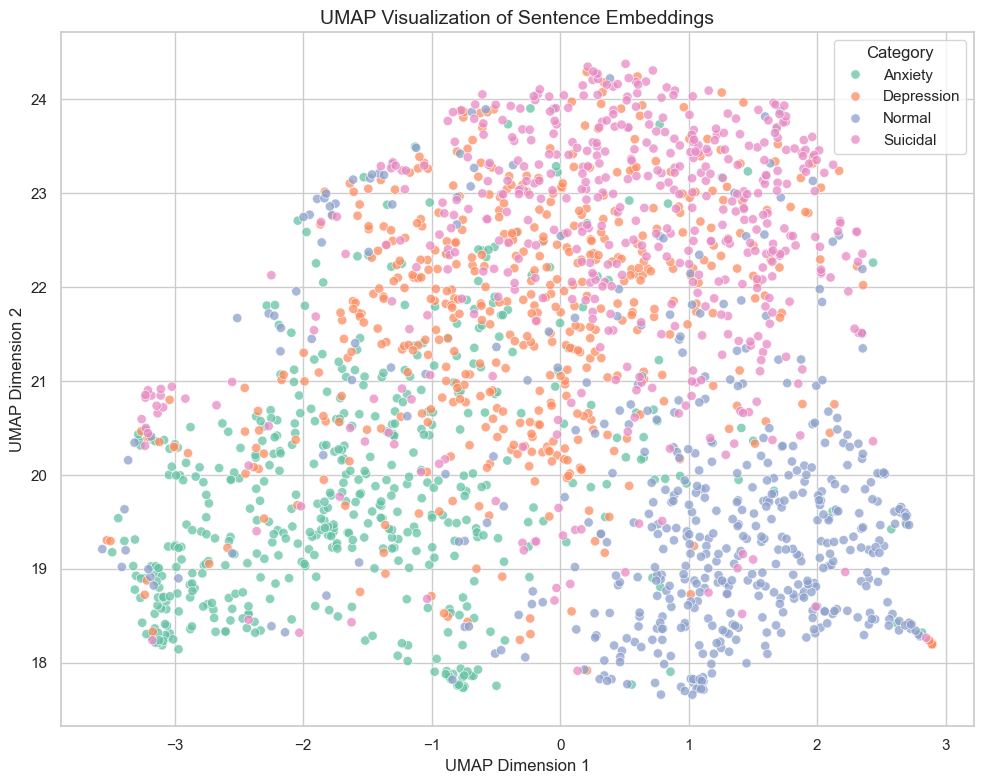

In [26]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x="x",
    y="y",
    hue="status",
    palette="Set2",
    alpha=0.75,
    s=45
)

plt.title("UMAP Visualization of Sentence Embeddings", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Category")
plt.tight_layout()
plt.show()